> Hypothesis - Gördüğüm fark gerçek mi, yoksa tesadüf mü?

> Gördüğüm fark gerçek mi, yoksa rastgele oluşmuş olabilir mi?

> Çünkü gerçek dünyada veriler her zaman gürültülüdür (noise).

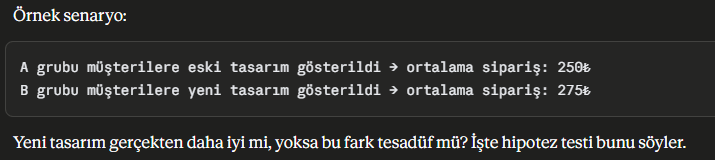
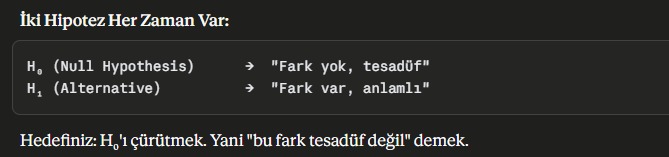

#### p-value

In [11]:
# p-value is probability value ==> 0.05 nereden geliyor? Konvansiyonel eşik — %5 yanılma payı kabul ediyoruz.
# p-val < 0.05 H₀ reddedilir → fark anlamlı ✅
# p-value > 0.05  →  H₀ reddedilemez → fark tesadüf olabilir ❌
# butun olay bu H0-i curutmek icindir. eger p-val kucukse o zaman H0 reddedilir. 



# !Eğer H₀ doğruysa, gözlediğim kadar büyük bir farkı görme olasılığı nedir?
# 0.06 => H0 dogru ==> reddedilemez, esikten buyuk demek sans eseri proabibility
# 0.001 => H0 hatali ===> reddedilir, sans eseri cok kucuk kabul edilebilir degil
# demek p-value - bir filterdir

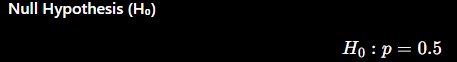

In [ ]:
# yani H0 icin olasilik her zaman %50-dir, dolayisiyla p=0.5

In [ ]:
# Type I Error => False Positive => Gercekte fark yok => hatali var denildi
# Type II Error => False Negative => Gercekte fark var = hatali yok denildi

#### T-TEST

In [ ]:
# T-STATISTICS

In [ ]:
from scipy import stats

#ttest iki grub arasindaki farki anlamak icin
# iki gruptan cok gruplular icin ANOVA kullanilir

A_grubu = [250, 230, 270, 245, 260, 255, 248, 265]
B_grubu = [275, 290, 268, 285, 272, 280, 295, 278]

t_stat, p_val = stats.ttest_ind(A_grubu, B_grubu)
print(f'p-val: {p_val:.4f}') # p_val is = 0.0002 so H0 reddedilir
print(t_stat)

if p_val < 0.05:
    print("Fark anlamlı → yeni tasarım gerçekten daha iyi")
else:
    print("Fark tesadüf olabilir → tasarım değişikliği işe yaramadı")

p-val: 0.0002
-4.99300467239642
Fark anlamlı → yeni tasarım gerçekten daha iyi


### ANOVA

In [ ]:
# F-STATISTICS

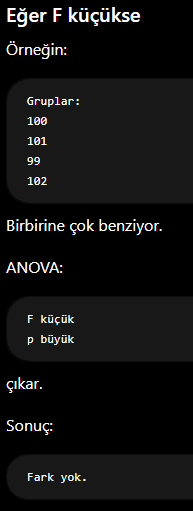
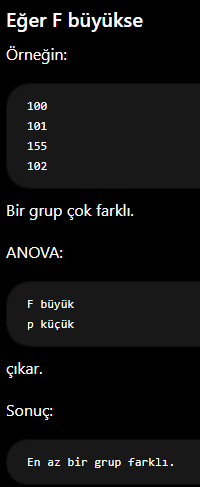

In [ ]:
# ANOVA — İkiden Fazla Grup:
# T-test sadece 2 grup karşılaştırır. 3+ grup varsa ANOVA kullanılır.
# Birden fazla grubun ortalamalari arasinda fark var mi? 
# eger 3 grubu t_test ile mesela AB, AC, BC yapilabilinir, ama grup sayisi arttikca risk alarm payi da artiyor, o yuzden
# sakincali ==> Anova bunu tek test ile cozer
# Anovanin hipotezi H0 gruplarin ortalamalari esit meanA=meanB=meanC. H1 en az bir grup farkli. Ama hangi grup soyleyemez
# ! Anova 2 varyansi karsilastirir. Grup ici varyans - ayni grup icindeki dagilma. Gruplar arasi varyans - A grup ile B grup
# ortalamasi arasindaki fark. 
# ! EGER GRUP ICI VARYANS KUCUK, GRUPLAR ARASI VARYANS COK BUYUKSE, O ZAMAN GERCEK FARK VARDIR. 


# !ANOVA şunu sorar:  Grup ortalamaları arasındaki fark, grupların kendi içindeki doğal oynaklıktan daha büyük mü?

kampanya_A = [200, 210, 195, 205, 198]
kampanya_B = [250, 265, 245, 258, 252]
kampanya_C = [230, 225, 235, 228, 232]

f_stat, p_value = stats.f_oneway(kampanya_A, kampanya_B, kampanya_C)
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Gruplar arasında anlamlı fark var")
else:
    print("Fark tesadüf olabilir")

# !Dikkat: ANOVA "fark var" der ama hangi gruplar arasında demez. Bunun için Post-hoc test gerekir:
# Eger Anova testi anlamliysa o zaman tukey (post-hoc) testi yapilir

p-value: 0.0000
Gruplar arasında anlamlı fark var


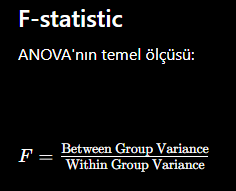

#### POST-HOC

In [ ]:
# Post-hoc test ====> Hangi grupta farkin var oldugunu soyler, yani ANOVA nin soylemedigini soyler
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

degerler = kampanya_A + kampanya_B + kampanya_C
gruplar = ['A']*5 + ['B']*5 + ['C']*5

tukey = pairwise_tukeyhsd(degerler, gruplar)
print(tukey)
# A vs B → p < 0.05 → anlamlı fark var
# A vs C → p > 0.05 → fark yok
# B vs C → p < 0.05 → anlamlı fark var

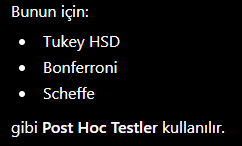

### ANCOVA

In [ ]:
# Anova + Covariance
# Anova + Regression (Covariance)

# Grupları karşılaştırırken, sonucu etkileyebilecek başka bir değişkenin etkisini temizlemek.
# ANOVA'dan farkı: Bir kontrol değişkeni eklersin.
# !3 kampanya karşılaştırıyorsun — ama müşterilerin yaşı da satışı etkiliyor. 
# ! Yaşı kontrol altına alarak kampanyaları karşılaştırmak istiyorsun. yani yas etkeninin etkisini temizliyorsun, 
# karsilastirmada gercekleriyle yaristiriyorsun

# Grupları karşılaştırmak istiyorsun + bir değişkenin etkisini kontrol altına almak istiyorsun → ANCOVA


# "Gruplar arasında fark var mı?" sorusunu, sonucu etkileyen diğer sayısal değişkenlerin etkisini temizleyerek cevaplayan yöntemdir. 
# ANOVA yalnızca grup farklarına bakarken, ANCOVA grup farklarını daha adil ve daha gerçekçi biçimde değerlendirir.

# ANCOVA genellikle şu durumda kullanılır:

# Grupları karşılaştırmak istiyorum ama sonucu etkileyen başka bir sürekli değişken de var.

# Örnekler:

# Eğitim yöntemi + ön test puanı
# İlaç + başlangıç sağlık durumu
# Reklam kampanyası + bütçe
# Cache stratejisi + trafik yükü
# Dil dönemi + metin uzunluğu



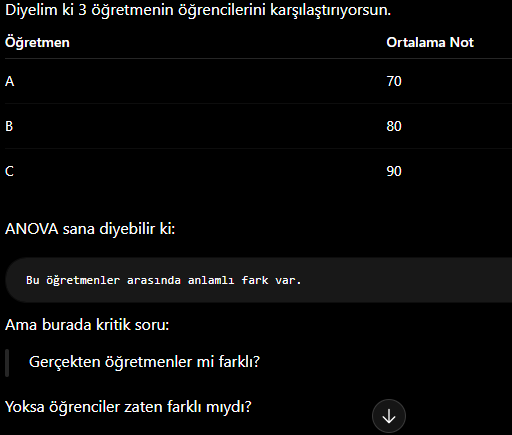
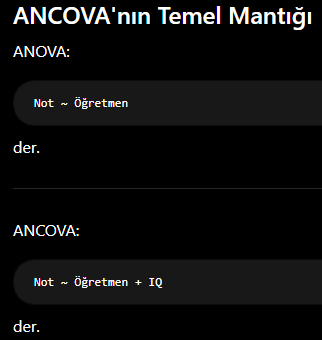

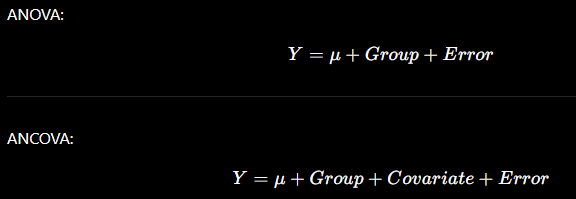
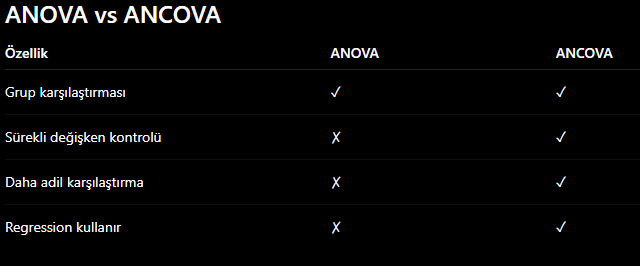

In [ ]:
# yani:
# IQ etkisini çıkardıktan sonra öğretmenler arasında fark kalıyor mu? sorusunu sorar.


# Dependent variable => sonuc degiskeni - sinav notu
# Factor => Gruplar - ogretmen
# Coavariate => kontrol etmek istedigimiz surekli degisken - IQ

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# yas = kovaryat (kontrol değişkeni)
model = ols('satis ~ C(kampanya) + yas', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

In [ ]:
# Veri Biliminde Nerede Kullanılır?
# A/B Testing
# Reklam performansı
# Model karşılaştırma
# API performans analizi
# NLP model değerlendirme
# Dilbilimsel dönem karşılaştırmaları
# Sensör verisi analizleri

# Bu yüzden hipotez testi ve ANOVA'nın özü aslında şudur:

# "Gözlediğim fark gerçek bir etki mi, yoksa veri içindeki rastgele dalgalanmalardan mı kaynaklanıyor?"

> 2 grup karşılaştır              →  T-test

> 3+ grup karşılaştır             →  ANOVA

> 3+ grup + kontrol değişkeni     →  ANCOVA

> Hangi gruplar farklı            →  Tukey post-hoc

> Normallik kontrolü              →  Shapiro-Wilk (p > 0.05 → normal)

> Kategorik ilişki ->               Chi-square

> Sürekli değişken ilişkisi       -> Correlation